## Example 1: Seismic Model Generation

This example demonstrates the use of **ModGen2D** to generate **spatially correlated seismic property fields** for a typical **P-wave refraction scenario**.

In this notebook, we will:

- Construct a simple **one or two-layered geological model** with a defined **groundwater table**.
- Generate a **shared z-score field** to control spatial variability.
- Use the shared z-score realization to produce **correlated P-wave velocity (Vp) and mass density (ρ)** fields.
- **Special Case** - Using ".csv" for multiple material types for each features.

This example highlights how ModGen2D enables the generation of **physically consistent, spatially heterogeneous seismic models** suitable for uncertainty quantification, sensitivity analysis, and training data generation for seismic inversion.

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import pandas as pd
import numpy as np
import modgen2d as mg
import example1_helper_functions as hf

# Example settings
has_surface = True  ## Model generation example type: True if has soil-air interface, else False.
layer0_flag = True #Must be true is has_surface is True. If has_surface False, it can be False.
generate_obstacles = False 
seed = 17

## Step 1: Unit Configuration

Define the units for the computational process. There are **two units**:

- **`domain_length_unit`** (`str`)  
  - Unit used **internally** by the computational domain (e.g., `'cm'`).  
  - Typically **smaller** or discretized so that all domain lengths (spans, dls) are **integers** in this unit.

- **`physical_length_unit`** (`str`)  
  - Unit used **externally** by the user (e.g., `'m'`).  
  - Represents the **real-world scale** and is used throughout for input/output.

> Note: All computations are performed in the **domain unit**, but all user interactions use the **physical unit**.


In [3]:
units_config = mg.Units("m", "cm", conversion_factor=100) #mg.Units() also have same arg values

## Step 2: Properties Definition

In this step, we define the **features and their properties** within the domain.  

Properties can become as complex as needed, depending on:
- The number of **feature types** (e.g., soil, utilities, karst)
- The number of sub-types of each features.
- Conditions of the features (e.g., wet/dry soils)
- Type of random generators for each feature (Uniform, Constant etc.)

Since, in this example, we have multiple sub-types for soils, and each have their own wet/dry soils properties. We will create a helper function to add material using **csv_file**. For more simpler example, refer to Example 3: Large geology.

For simplicity, this example splits Step 2 into **four sub-steps**:
1. **General Definitions** – basic setup and parameters.  
2. **Feature Configuration** – define which materials belong to which features.  
3. **Main Properties** – assign physical properties like density, velocity, etc.  
4. **Auxiliary Properties** – any extra properties needed for modeling.

### Step2.1: General Definitions

In [4]:
# Domain dimensions
x_span = 5          # Domain length in X-direction (domain units)
z_span = 3          # Domain depth in Z-direction (domain units)

# Grid spacing
del_xz_final = 0.1       # Base spacing for the domain
del_xz_obs = del_xz_final / 10  # Finer spacing for obstacles (recommended: 1/10)

# Interface interpolation method
remesh_interp_method = 'linear'

# Spatial correlation parameters
spatial_theta_x = 100  # Correlation length in X
spatial_theta_z = 0.5  # Correlation length in Z

# Random number generator (for reproducibility)
rng = np.random.default_rng(seed=seed)

### Step 2.2: Features Configuration

In [15]:
soil_props_csv = pd.read_csv('data/soil_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')

# Initialize feature configuration
feature_config_instance =  mg.FeaturesConfig()

# Define material distributions
# For this example, we have multiple types of soil types and P(each type of soil) is same. 
soil_materials_distribution = mg.random_generators.DiscreteChoice(x = soil_props_csv.index.tolist(), rng=rng)

# Add features to feature_config_instance
feature_config_instance.add_feature('def', soil_materials_distribution, feature_description = 'def means soil.')


if generate_obstacles:
    # If there are utilities to add.
    utils_props_csv = pd.read_csv('data/utils_properties.csv', index_col=0).apply(pd.to_numeric, errors='coerce')
    utils_materials_distribution = mg.random_generators.DiscreteChoice(x = utils_props_csv.index.tolist(), rng=rng)
    feature_config_instance.add_feature('U', utils_materials_distribution, feature_description = 'utility features')


### Step 2.3: Main Properties

In this step, we define **main physical properties** for each feature in the domain (e.g., shear wave velocity `vs`).
Main property refers to all the properties that is to be "simulated".

Each property can have different values for wet and dry conditions. 
- **Wet / Both conditions**  - If dry condition is not provided (is None), then it refers to "both". ie (wet and dry condition are same)
- **Dry conditions** (optional)  

We also define **layer0 values**, which represent property values of **water if wet; air if dry**; needed if the model has a **non-horizontal ground surface**, so layer0 properties are applied accordingly.

In [6]:
#2.3.1 Main Properties config definition
main_properties_config_instance = mg.MainPropertiesConfig(feature_config_instance, layer0_flag=layer0_flag)

cov_dc_ec = mg.random_generators.Constant(0.05, rng)
main_properties_info = {'vs': {'desc':'Shear wave velocity in m/s', 'cov': cov_dc_ec, 'layer0':[20, 20]}, 
                       'miu': {'desc':"Poisson's ratio", 'cov': None, 'layer0':[0, 0.4999]},  
                       'rho': {'desc':"Density", 'cov': cov_dc_ec, 'layer0':[1.2, 1000]}}



for main_property_name, main_props_vals in main_properties_info.items():
    #2.3.2 Define each MainProperty instance
    main_property_instance = mg.MainProperty(main_property_name, feature_config_instance, layer0_flag=layer0_flag, description=main_props_vals['desc'])

    #2.3.3  Define wet and dry properties for each features' each materials (including layer 0  for 'def' if flag is True)
    ## For Feature 'def'; material type 'all'
    main_property_instance = hf.add_features_from_pd(rng, main_property_instance, main_property_name, 'def', pd_dataframe=soil_props_csv, cov_distribution = main_props_vals['cov'], cov_type='cov')
    
    if generate_obstacles:
        main_property_instance = hf.add_features_from_pd(rng, main_property_instance, main_property_name, 'U', pd_dataframe=utils_props_csv, cov_distribution = main_props_vals['cov'], cov_type='cov')
    
    ## For Feature 'def'; material type 'layer0'
    if layer0_flag:
        air_val, water_val = main_props_vals['layer0']
        main_property_instance = hf.add_layer0(rng, main_property_instance, main_property_name, air_val, water_val)

    # 2.3.4 Add MainProperty to MainPropertiesConfig instance
    main_properties_config_instance.add_main_property(main_property_instance)

main_properties_config_instance.print()

Main_Properties: ['vs', 'miu', 'rho']
feature_ids: ['def']
---------------------------
Property Name: vs
Description: Shear wave velocity in m/s
All Feature IDs: ['def']
Properties:
{'def': {'Fat Clays': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A876DDF0>},
         'Lean Clays': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F920>},
         'Silts': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F9C0>},
         'Loose Sand': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F8D0>},
         'Dense Sand': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F510>},
         'Gravel': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F600>},
         'Weathered Rock': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x00000112A898F5B0>},
     

### Step 2.4: Auxiliary Properties

Auxiliary properties are not simulated directly but are required for model generation like number of soil layers, etc.
Think of auxiliary properties as a collection of random generators or configuration values that support the simulation.

You can define them using a dictionary too.

In [7]:
# Define some additional Properties
aux_props = mg.AuxillaryProperties()
aux_props.add_aux_property('n_layers',  mg.random_generators.DiscreteChoice(x=[1,2], p=[0.3, 0.7], rng=rng))
aux_props.add_aux_property('gwt', mg.random_generators.Uniform(0, z_span, rng))

if generate_obstacles:
    utilities_sett={
        'n_obs': mg.random_generators.DiscreteChoice([0,1,2,3], rng=rng),
        'obs_shape': mg.random_generators.DiscreteChoice(['circ2d', 'rect2d',], [1/2, 1/2], rng=rng),
        'dia_obs':mg.random_generators.Uniform(1, 3, rng=rng), 
        'lh_obs':mg.random_generators.Uniform(1, 3, rng=rng), 
        'obs_x_coord':mg.random_generators.Uniform(0, x_span, rng=rng), 
        'depth_top_dist':mg.random_generators.Discrete2ContinuousPDF([0,5], p = [1,.2], new_del_x = 1, rng=rng), #Continuous distribution: discrete to be converted into continuous: also
    }
    
    aux_props.add_aux_property('n_obs', utilities_sett['n_obs'])
    aux_props.add_aux_property('obs_shape', utilities_sett['obs_shape'])
    aux_props.add_aux_property('dia_obs', utilities_sett['dia_obs'])
    aux_props.add_aux_property('lh_obs', utilities_sett['lh_obs'])
    aux_props.add_aux_property('obs_x_coord', utilities_sett['obs_x_coord'])
    aux_props.add_aux_property('depth_top_utils', utilities_sett['depth_top_dist'])
    
aux_props.print()

Additional_Properties: dict_keys(['n_layers', 'gwt'])


## Step 3: Model Definition

In this step, we define the computation **domain2d**, **geological interfaces**, **2D lithological model**, and simulation of **generated model2d**.
This step connects everything defined earlier (units, features, properties) into an actual **2D subsurface model**.

### Step 3.1: 2D Domain Definition

The domain defines the **size and resolution** of the model grid.

In [8]:
domain_final = mg.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, units_config)

### Step3.2: Interface Definitions

Interfaces define the layer boundaries (e.g., soil layers, ground surface). 

Defining interfaces using a **dictionary** is the recommended approach, as it:
- Follows the **default and best-practice workflow** automatically  
- Allows flexible configuration without changing core code  
- Supports a **wide variety of interface generation methods** (flat, rough, random, filtered, eroded, etc.)

Another approach is to use the **`DiscretizedInterfaces2D`** class directly.  
This approach provides **more direct control** and is **more powerful for complex workflows**, but it requires manual setup of multiple steps and can be more cumbersome.

This approach makes it easy to experiment with different geological scenarios while keeping the model setup clean and reproducible.

<Axes: xlabel='Distance', ylabel='Depth'>

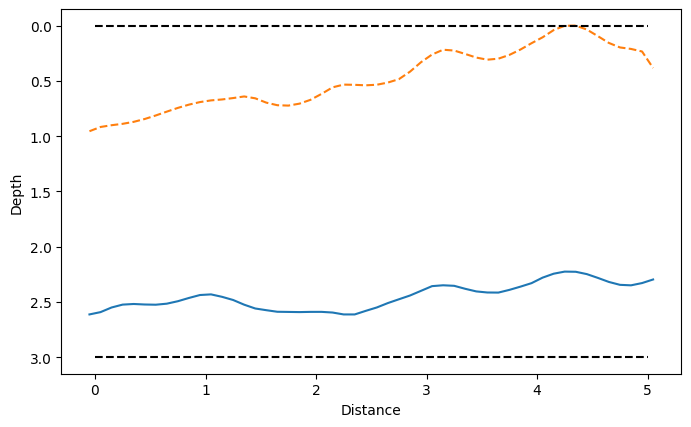

In [9]:
surface_factor = 1.5 if has_surface else 0

interface_sett= {
    'generate_surface':has_surface,  # Generate ground surface

    # Parameters for step 1: Generation of rough interfaces
    'rough_interface_creator_instance':mg.rough_interface_creator2d.UniformInterfaceGen(1, rng=rng),
    'rough_interface_generator_scale': [surface_factor,1.3,1.2,1], 
    # If number of layers > length of list, last value is reused

    # Parameters for step 2: Filtering
    'filter_settings': {
                 'filter_window_length':21, # must be odd
                 'filter_polyorder':7,
                        },

    # Parameter for Step 3: Interface Initial Points Generation
    'interfaces_depths_generation':'random', 
    'interfaces_depth_reference_point_x':None,
    
    # Parameter for Step 4: Handling the overlapping.
    'processing_settings': {
                'simulate_erosion': True,
            }
    }

n_layers = aux_props.aux_properties['n_layers'].generate()
gwt_depth = aux_props.aux_properties['gwt'].generate()

# DiscretizedInterfaces2D from dictionary definition
soil_interface = mg.DiscretizedInterfaces2DFromDict(domain_final, n_layers, interface_sett, remesh_interp_method=remesh_interp_method, rng=rng)
soil_interface.plot()

### Step 3.3: Lithological Domain (2D) Definition  
#### Step 3.3.1: From Interfaces (Global Soil Interface Configuration)

In this section, we first set and fix a global soil interface configuration.  
This global configuration is used internally and checked later to ensure the interface has not changed.

Important: For a single model, the global soil interface configuration must remain consistent throughout the workflow.

Once the global interface is fixed, we use a simple helper function to generate the 2D lithological domain directly from this global configuration.


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

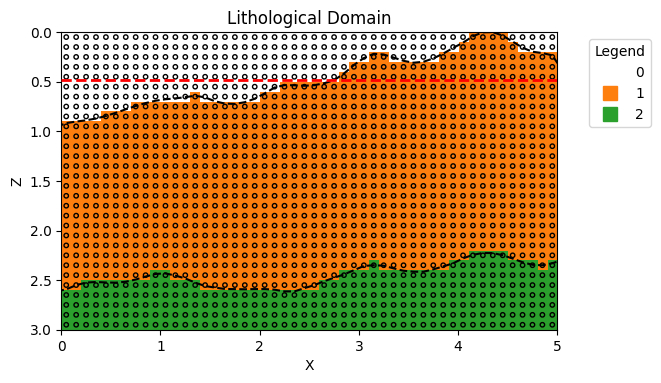

In [10]:
# Reset global soil interface configuration (safety step)
mg.GlobalSoilInterfaceConfig.reset()   # For safety only

# Register soil interface
mg.GlobalSoilInterfaceConfig.set_soil_interface(soil_interface)

## Get lithological domain from interface
name = 'soil_lit'
lit = mg.LithologicalDomain2D(domain_final, gwt_depth, name)
lit.plot(discrete_point_size = 10, plot_interfaces=True)

#### Step 3.3.2: From Obstruction2D (Global Soil Interface Configuration)

In this section, we first initialize a **`LithologicalDomain2DFromObstruction2D`** instance, which will be used to incrementally construct the lithological domain.  
For each subsurface feature, an obstruction is defined using the **`Obstruction2D`** class.

Random generators may be used to define the required parameters, such as the shape, size, and other geometric properties of the obstructions (if applicable).

Once an obstruction is defined, it is added to the previously initialized `LithologicalDomain2DFromObstruction2D` instance to update the lithological domain.

> Note: Skip this if no obstacles to be generated


In [11]:
if generate_obstacles:
    ## Define a LithologicalDoamin2d From obstruction 2d.
    obs_lit = mg.LithologicalDomain2DFromObstruction2D(domain_final, 'obstructions')
    
    # Number of obstructions to generate
    n_obs = 0#aux_props.aux_properties['n_obs'].generate()
    
    # Randomly generate obstruction shapes
    obs_shapes = aux_props.aux_properties['obs_shape'].generate((n_obs,))
    
    # For each obstruction, create a Obstruction2D instance first, and then add to obs_lit. 
    for i, obs_shape in enumerate(obs_shapes):
        # Generate obstruction location
        obs_x_coord = aux_props.aux_properties['obs_x_coord'].generate()
        d_obs = aux_props.aux_properties['depth_top_utils'].generate()
    
        # Unique obstruction ID
        obs_id = i+1
    
        # Initialize Obstruction2D object
        obs_instance = mg.Obstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)
    
        # Define obstruction geometry
        if obs_shape == 'circ2d':
            d = aux_props.aux_properties['dia_obs'].generate()
            obs_instance.circle_2d(d, obstruction_id = obs_id)
        elif obs_shape == 'rect2d':
            lx = aux_props.aux_properties['lh_obs'].generate()
            lz = aux_props.aux_properties['lh_obs'].generate()
            obs_instance.rectangle_2d(lx, lz, obstruction_id = obs_id)
        else:
            raise ValueError(f"Invalid util_shape {obs_shape}")
        # obs_instance.plot()
    
        ## Add Obs2D into defnined lit_domain_from_obs2d 
        obs_lit.add_obstruction2D(obs_instance, shift_ref2d_to_xy = [obs_x_coord, d_obs], feature_id='U')
    
        # Plot lithological domain generated from obstructions (JUST FOR VISUALIZATION)
        obs_lit.plot()
        
    
    # Visualize merged lithological domain (JUST FOR VISUALIZATION)
    merged_lit = lit.return_merged_lithological_domain([obs_lit], warn_if_null_lithological_domain=False)  # Just to see how merged lit. Karst to be added later.
    merged_lit.plot()


### Step 3.4: Lithological Domain Collection

In this step, we combine multiple lithological domains (e.g., soil layers, karst features, utilities) into a single **lithological domain collection** class instance.

The `LithologicalDomain2DCollection` class:
- Acts as a **container** for all lithological domains used in the model
- Ensures **feature consistency** across domains
- Controls **merging order and validation**
- Prevents accidental modification once finalized

The collection is initialized using the list of feature IDs defined in the main properties configuration.  
The `interface_set_name` identifies the soil interface configuration used as the global reference.


In [12]:
# Initialize lithological domain collection
lit_collection = mg.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 

# Add soil-based lithological domain
lit_collection.add_lithological_domain_from_soil_interface_config(lit)

if generate_obstacles:
    lit_collection.add_lithological_domain_from_obstruction2d("obs", obs_lit, warn_if_null_lithological_domain=False)
# Finalize and lock the lithological domain collection
lit_collection.lock()


### Step 4: Generate Simulated Property Profiles

For this example, we will generate **multiple realizations of the main property profiles** (`vs`) across the lithological domain.  

Key points "For this example":  
- Each realization uses the **same lithological domain and property distributions**.  
- The **spatial pattern varies** due to the spatial simulator, demonstrating variability in property fields.  
- We also manually override the top layer (`rock`) properties for this example.


In [13]:
# Unlock main properties config to allow sampling
main_properties_config_instance.unlock()

# Sample property values for all features in the lithological domain
main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)

# Initialize spatial simulator (controls spatial correlation)
spatial_sim = mg.spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng = rng)

# Generate property profiles using the spatial simulator
gen_profiles = mg.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
gen_profiles.simulate_zvals_property_profile('z_vals_seismic')
gen_profiles.simulate_profile_from_zvals_property_profile('vs', 'z_vals_seismic')     
gen_profiles.simulate_profile_from_zvals_property_profile('rho', 'z_vals_seismic')     
gen_profiles.simulate_profile_from_zvals_property_profile('miu', 'z_vals_seismic')           

#Save the profiles into h5 files
i = 0
gen_profiles.save_to_hdf5(f'generated_h5_files/{i:08d}.h5', hdf5_compression_level=8)

Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 0
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Data saved to generated_h5_files/00000000.h5


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\modgen2d\spatial_simulator2d.py:345: UserWarning: Layer 0 (wet): sigma=0 but 52 values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\modgen2d\spatial_simulator2d.py:356: UserWarning: Layer 0 (dry): sigma=0 but 183 values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\modgen2d\spatial_simulator2d.py:360: UserWarning: Layer 2 (dry): sigma=75.58371342227277 but all simulated values are zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\modgen2d\spatial_simulator2d.py:345: UserWarning: Layer 2 (wet): sigma=0 but 275 values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\modgen2d\spatial_simulator2d.py:307: UserWarning: Layer 1: sigma=0 but 990 z-values are non-zero.
  warnings.warn(


(<Axes: title={'center': 'Main_property_name:z_vals_seismic'}, xlabel='X', ylabel='Z'>,
 np.float64(-2.0327584296595087),
 np.float64(5.380009619388266))

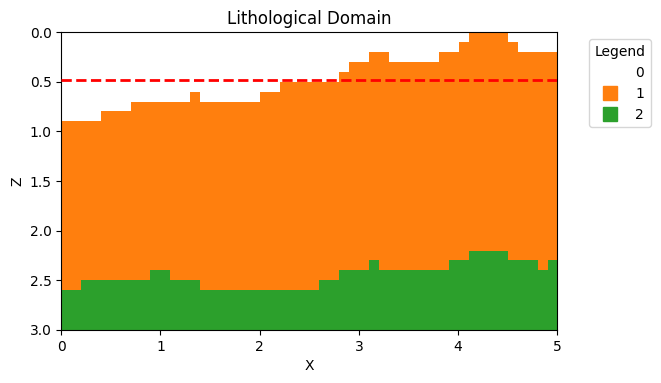

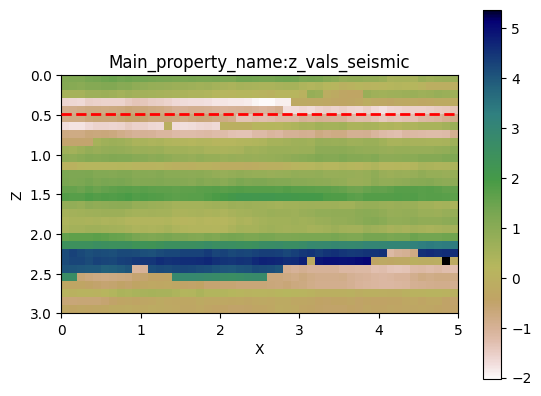

In [14]:
gen_profiles.merged_generated_model2d.plot_lit_domain()#'z_vals_seismic')
gen_profiles.merged_generated_model2d.plot_profile('z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')